# Quantum Sensing Delay Line — Summary & Exploration

The **quantum sensing** model: audio is phase-encoded into a qubit (NV-center
Ramsey magnetometry picture), pushed through a partial-SWAP quantum delay line,
and *decoded back from the quantum channel only* — the output is the
$\langle\sigma_z\rangle$ readout of the delay-line qubit, nothing else.

Head-to-head comparator throughout: **Rocchesso's QFDN** (2-delay
marginal-probability variant, delays matched to the sensing delay line).
All comparisons use the **single-channel** sensing line and the
**post-measurement** readout (the dual/joint mode is left aside here).

Structure:
1. Theory & equations
2. The signal-processing chain, made explicit (encoding, ticking clock, post-chain)
3. Impulse response — sensing vs QFDN
4. Bass notes — sensing vs QFDN (listen)
5. Audio input — sensing vs QFDN (listen)
6. Quantum part alone: IR at different **delays**
7. Quantum part alone: IR at different **swap rates** (coupling)
8. **Pre- vs post-measurement** readout
9. Encoding-depth sweep: `phase_scale` (the sensing analogue of the
   dependent-trajectory `OMEGA_S_RES` physics sweep)

## 1. Theory

**1.1 Phase encoding (signal → quantum phase).** The audio $b(t)$ plays the role
of the AC magnetic field an NV-center magnetometer senses. During sensing cycle
$n$ — one cycle per output sample, period $T_{\rm seq}=1/f_s$ — the qubit
accumulates the phase

$$\varphi[n] \;=\; \gamma_{\rm eff}\int_{nT_{\rm seq}}^{nT_{\rm seq}+T_\varphi}
g(t)\,b(t)\,dt,\qquad \gamma_{\rm eff}=\frac{\texttt{phase\_scale}}{T_\varphi},$$

with switching function $g(t)\equiv 1$ for a Ramsey sequence ($\pm1$ around the
$\pi$-pulse for Hahn echo). Since $T_\varphi=0.8\,T_{\rm seq}$ and the input is
slowly varying on that scale, $\varphi[n]\approx\texttt{phase\_scale}\cdot\bar b[n]$:
**the sample value *is* the quantum phase.**

**1.2 The Ramsey readout circuit (phase → population).**

$$U_{\rm enc}(\varphi)=R_y(-\tfrac{\pi}{2})\,R_z(\varphi)\,R_x(\tfrac{\pi}{2}),
\qquad \langle\sigma_z\rangle_{\rm ideal}=\sin\varphi[n]$$

— linear for small $\varphi$, folding once $|\varphi|\gtrsim\pi/2$
(§9 sweeps this nonlinearity).

**1.3 The delay line (partial-SWAP collision model).** A register
$S\otimes D_0\otimes\cdots\otimes D_{d-1}$ is maintained and **never
re-initialised**. The only coupling is the partial swap

$$U_{\rm SWAP}(\theta)=\cos\theta\;\mathbb{1}+i\,\sin\theta\;\mathrm{SWAP},
\qquad\text{population transfer }\sin^2\theta .$$

Each tick $n$:
1. encode $\varphi[n]$ on $S$ via $U_{\rm enc}$;
2. $\mathrm{SWAP}_{\rm in}(\theta_{\rm in})$: $S\leftrightarrow$ fresh vacuum qubit —
   pushes the encoded state into the line ($S$ keeps a residual → memory);
3. $\mathrm{SWAP}_{\rm out}(\theta_{\rm out})$: $S\leftrightarrow D_0$ (the oldest
   delay qubit) — the memory/back-action coupling;
4. read the output sample $y[n]=\langle\sigma_z\rangle_{D_0}$;
5. trace out $D_0$; the fresh qubit becomes the newest line element.

The echo time is $d/f_s$ seconds.

**1.4 Two readouts.**
* **post-measurement** (default in every comparison here): read $D_0$ *after*
  the $\mathrm{SWAP}_{\rm out}$ interaction — the sample carries the back-action
  of the memory coupling. (This was consistently the more distinct-sounding
  readout.)
* **pre-measurement** (`exp_feed_back`): read $D_0$ *before* any swap
  (expectation-value readout is non-destructive), then apply a **strong**
  feedback swap $\theta_{\rm fb}$ that recirculates $D_0$ back into $S$ — an
  explicit reverb loop; $\theta_{\rm fb}$ is the loop-gain / reverb-time knob
  ($\theta_{\rm fb}=\pi/2$ ≈ lossless).

**1.5 Quantum-as-carrier.** The output is *only* the decoded
$\langle\sigma_z\rangle$ of the delay-line qubit. Post-processing is restricted
to global, input-independent operations: mean removal, 15 Hz high-pass, one
impulse-calibrated scalar gain (compensating the $\cos^2\theta_{\rm out}$ read
attenuation), and raised-cosine edge fades. No sample of the input is ever
routed, mixed or blended into the output.

**1.6 The comparator — Rocchesso's QFDN (2-delay marginal variant).**
QPAM amplitude encoding $p[n]=\tfrac12(x[n]+1)$; two classical delay lines carry
the *marginal probabilities* of a 2-qubit state; feedback through the comb-gate

$$G\otimes G,\qquad G=Z\,R_y(\vartheta)$$

($\vartheta=-\tfrac\pi2$ → Hadamard; here $\vartheta=-\pi/16$, Rocchesso's
intermediate-decay example, with `fCoef` pulled to 0.61 so the tail decays).

## 2. Parameters & imports

In [1]:
import numpy as np, matplotlib.pyplot as plt, soundfile, os
from scipy.signal import resample, butter, filtfilt
from IPython.display import Audio, display
from quantum_audio_master import trotterize_sensing, _compute_phases_from_signal
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

FS          = 8000            # sensing rate = output sample rate (one Ramsey circuit per sample)
PHASE_SCALE = 0.5             # encoding depth: phi[n] ~ PHASE_SCALE * b[n]
SWAP_IN     = 0.9             # theta_in  — encode -> line transfer (sin^2 = 0.61)
SWAP_OUT    = 0.9             # theta_out — line -> readout back-action coupling
FB_ANGLE    = 1.0             # pre-measurement mode: strong feedback swap angle (reverb loop gain)
SINGLE_D    = 7               # delay-line length (samples); Hilbert dim = 2^(d+2)
FAST        = True            # sparse-local unitaries — bit-identical, faster

# Rocchesso QFDN comparator (2-delay marginal variant, matched delays)
QFDN_DELAYS   = (7, 11)       # first delay matched to SINGLE_D
QFDN_FCOEF    = 0.61          # pulled down from 0.99 so the tail decays
QFDN_FB_THETA = -np.pi/16     # comb-gate angle (Rocchesso's intermediate-decay example)

# test signals
NOTE_FREQS = [65.41, 82.41, 98.00]        # C2 E2 G2
NOTE_DUR, SIL_DUR = 0.20, 0.60            # s
AUDIO_PATH = 'audio/windchimes.wav'
AUDIO_SEC, START_S = 7.0, 48.0
ONSET_MS, FADE_MS = 40.0, 40.0            # presentation fades
print(f'FS={FS}  d={SINGLE_D}  swap_in/out={SWAP_IN}/{SWAP_OUT}  phase_scale={PHASE_SCALE}  '
      f'QFDN delays={QFDN_DELAYS} fCoef={QFDN_FCOEF}')

FS=8000  d=7  swap_in/out=0.9/0.9  phase_scale=0.5  QFDN delays=(7, 11) fCoef=0.61


## 3. Rocchesso's QFDN engine (Qiskit, verbatim processing loop)

The 2-delay **marginal-probability** variant (Cell 15 of `QFDN.ipynb`) — the
apples-to-apples match for single-channel sensing (one system qubit).

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector, partial_trace

class CircularBuffer:
    """circular buffer (verbatim from Rocchesso)"""
    def __init__(self, size_max, init_value):
        self.max = size_max
        self.data = np.zeros(self.max, dtype='complex_') + init_value
        self.cur = 0
    def put(self, x):
        self.data[self.cur] = x
        self.cur = (self.cur + 1) % self.max
    def get(self):
        return self.data[self.cur]

HOUSEHOLDER = [[-.5,.5,.5,.5],[.5,-.5,.5,.5],[.5,.5,-.5,.5],[.5,.5,.5,-.5]]

def _qfdn_combgate(theta):
    Z  = np.array([[1.0,0.0],[0.0,-1.0]])
    RY = np.array([[np.cos(theta/2), -np.sin(theta/2)],[np.sin(theta/2), np.cos(theta/2)]])
    return np.kron(Z @ RY, Z @ RY)
QFDN_FB_MATRIX = _qfdn_combgate(QFDN_FB_THETA)

def run_qfdn_marginal(input_signal, fs=FS, delay_lengths=QFDN_DELAYS,
                      fCoef=QFDN_FCOEF, matrix=None):
    """Rochesso QFDN: 2 marginal-probability delay lines, sum-normalise input.
    Processing loop is verbatim Cell 15 of QFDN.ipynb."""
    Matrix = (QFDN_FB_MATRIX if matrix is None else matrix)
    FDNgate = UnitaryGate(Matrix)
    FDN_circ = QuantumCircuit(2, 2)
    FDN_circ.append(FDNgate, [0, 1])
    qpam = np.clip(input_signal * 0.5 + 0.5, 0.0, 1.0)   # [-1,1] -> [0,1] QPAM
    N = len(qpam)
    m1, m2 = delay_lengths
    delay = [CircularBuffer(m1, 0.5), CircularBuffer(m2, 0.5)]
    stateIn = np.zeros(4) + 0.5; stateOut = np.zeros(4) + 0.5
    output = np.zeros(N)
    for n in range(N):
        aq = min(delay[0].get(), delay[1].get())
        stateOut[0] = np.sqrt(aq) * fCoef
        stateOut[1] = np.sqrt(delay[1].get() - aq)
        stateOut[2] = np.sqrt(delay[0].get() - aq)
        stateOut[3] = np.sqrt(1 - np.abs(stateOut[0])**2 - np.abs(stateOut[1])**2
                              - np.abs(stateOut[2])**2)
        delay[0].put(np.abs(np.diagonal(partial_trace(Statevector(stateIn), [1]))[0]))
        delay[1].put(np.abs(np.diagonal(partial_trace(Statevector(stateIn), [0]))[0]))
        sOut = Statevector(stateOut)
        output[n] = np.sqrt(sOut.probabilities([0])[0])
        sOut = sOut.evolve(FDN_circ)
        stateOut = sOut.data
        sIn = Statevector([qpam[n], np.sqrt((1-qpam[n]**2)/3),
                           np.sqrt((1-qpam[n]**2)/3), np.sqrt((1-qpam[n]**2)/3)])
        for i in range(4):
            stateIn[i] = np.sqrt((np.abs(sIn[i])**2 + np.abs(stateOut[i])**2)/2)
    return output - np.mean(output)

print('QFDN engine loaded: run_qfdn_marginal()')

QFDN engine loaded: run_qfdn_marginal()


## 4. Sensing runner + presentation helpers

`run_sensing_raw(sig, readout='post'|'pre')` is the *only* route to the quantum
channel. Everything shown/played passes through the same global post-chain
(§1.5): DC high-pass → calibrated stretch gain (post readout only) → edge fades.

In [3]:
def make_impulse(duration, fs=FS):
    x = np.zeros(int(duration*fs)); x[0] = 1.0
    return x

def make_base_notes(freqs=NOTE_FREQS, note_dur=NOTE_DUR, silence_dur=SIL_DUR, fs=FS):
    segments = []
    for i, f in enumerate(freqs):
        t = np.arange(int(note_dur*fs)) / fs
        env = 0.5 * (1 - np.cos(2*np.pi*t/note_dur))
        segments.append(np.sin(2*np.pi*f*t) * env)
        if i < len(freqs) - 1:
            segments.append(np.zeros(int(silence_dur*fs)))
    x = np.concatenate(segments)
    tail = max(int(1.0*fs), len(x)) - len(x)
    return np.concatenate([x, np.zeros(max(tail, int(0.3*fs)))])

def run_sensing_raw(sig, delay=None, swap_in=None, swap_out=None, readout='post',
                    fb_angle=None, phase_scale=None, encode_target='system'):
    """The quantum channel. readout='post': <sz> of D0 AFTER SWAP_out (back-action
    included). readout='pre': <sz> of D0 BEFORE any swap, then strong feedback
    swap (explicit reverb loop)."""
    d  = SINGLE_D if delay is None else delay
    si = SWAP_IN if swap_in is None else swap_in
    so = SWAP_OUT if swap_out is None else swap_out
    ps = PHASE_SCALE if phase_scale is None else phase_scale
    fa = FB_ANGLE if fb_angle is None else fb_angle
    t = 1.0 / FS
    kw = dict(exp_feed_back=True, feedback_swap_angle=fa) if readout == 'pre' else {}
    o = trotterize_sensing(sig, FS, 0.8*t, t, phase_scale=ps, delay=d,
                           swap_angle_in=si, swap_angle_out=so, method='sin_phi',
                           fast=FAST, encode_target=encode_target, **kw)['aux_sigma_z']
    return o - np.mean(o)

# ── global, input-independent post-chain (see §1.5) ──
def dc_filter(y, cutoff_hz=15.0, order=4):
    b, a = butter(order, cutoff_hz/(FS/2.0), btype='high')
    return filtfilt(b, a, y)

def fade_edges(y, fade_in_ms=FADE_MS, fade_out_ms=15.0):
    y = np.asarray(y, float).copy()
    ni, no = int(fade_in_ms*FS/1000), int(fade_out_ms*FS/1000)
    if 0 < ni < len(y): y[:ni]  *= 0.5*(1-np.cos(np.linspace(0, np.pi, ni)))
    if 0 < no < len(y): y[-no:] *= 0.5*(1+np.cos(np.linspace(0, np.pi, no)))
    return y

def _peak(y): y = y - np.mean(y); return float(np.max(np.abs(y)))

def apply_gain_clip(y, gain, ceiling=0.99):
    z = y*gain; pk = float(np.max(np.abs(z)))
    return z*(ceiling/pk) if pk > ceiling else z

def amplify_to_input(y, inp, exclude_onset_ms=ONSET_MS, ceiling=0.99):
    """One global scalar: match the output BODY level to the input (onset excluded)."""
    n0 = int(exclude_onset_ms*FS/1000); body = y[n0:] if 0 < n0 < len(y) else y
    g = np.max(np.abs(inp)) / (np.max(np.abs(body)) + 1e-12)
    return apply_gain_clip(y, g, ceiling)

# empirical stretch: ONE scalar, calibrated once on an impulse — compensates the
# cos^2(theta_out) attenuation of the post readout. Input-independent.
def calibrate_stretch_gain():
    imp = make_impulse(0.3)
    return _peak(dc_filter(run_sensing_raw(imp, swap_out=0.0))) / (
           _peak(dc_filter(run_sensing_raw(imp, swap_out=SWAP_OUT))) + 1e-12)
STRETCH_GAIN = calibrate_stretch_gain()
print(f'empirical stretch gain (post readout) = {STRETCH_GAIN:.3f}   '
      f'[analytic 1/cos^2(theta_out) = {1/np.cos(SWAP_OUT)**2:.3f}]')

def present(name, inp, traces, play=True, fade_in=None):
    """traces = list of (label, y, color). Everything DC-filtered + faded."""
    fin = 3.0 if fade_in is None and 'Impulse' in name else (fade_in or FADE_MS)
    flt = lambda y: fade_edges(dc_filter(y), fin)
    sigs = [('input [dc]', flt(inp), 'k')] + [(lab, flt(y), c) for lab, y, c in traces]
    fig, ax = plt.subplots(1, len(sigs), figsize=(4.8*len(sigs), 3.2))
    fig.suptitle(name, fontweight='bold')
    for a, (lab, y, col) in zip(np.atleast_1d(ax), sigs):
        a.plot(np.arange(len(y))/FS, y, col, lw=0.7)
        a.set_title(lab, fontsize=9); a.grid(alpha=.3)
        a.axhline(0, color='k', lw=.3); a.set_xlabel('s')
    plt.tight_layout(); plt.show()
    if play:
        for lab, y, _ in sigs:
            yr = apply_gain_clip(resample(y, int(len(y)*44100/FS)), 1.0)
            print(f'  {lab}   (peak {np.max(np.abs(yr)):.3f})')
            display(Audio(yr, rate=44100))

print('helpers loaded')

KeyboardInterrupt: 

## 5. The signal-processing chain, made explicit

The sensing analogue of the dependent-trajectory encode/tick machinery:

* **Encoding**: amplitude → *quantum phase* by integration over $T_\varphi$
  (`phase_scale` sets the depth; compare `AMP_POW` companding in the
  dependent-trajectory model, which encodes amplitude → *population*).
* **Ticking clock**: one Ramsey circuit per output sample — the collision clock
  runs at $f_s$, so a delay of $d$ ticks echoes after $d/f_s$ seconds
  (dependent-trajectory equivalent: one collision per STFT hop).
* **Post-chain**: DC high-pass + one impulse-calibrated scalar
  (the $\cos^2\theta_{\rm out}$ stretch) + edge fades — all global &
  input-independent.

Below: input $b(t)$ → accumulated phase $\varphi[n]$ → ideal single-shot readout
$\sin\varphi[n]$ → actual delay-line output (post readout, $d=7$).

In [ ]:
bass = make_base_notes()
t_seq = 1.0/FS
phases, _, _ = _compute_phases_from_signal(bass * PHASE_SCALE/(0.8*t_seq), FS,
                                           0.8*t_seq, t_seq, len(bass), 'ramsey')
y_line = run_sensing_raw(bass)

fig, ax = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
tt = np.arange(len(bass))/FS
ax[0].plot(tt, bass, 'k', lw=0.7); ax[0].set_title('input  b(t)  — bass notes C2 E2 G2')
ax[1].plot(tt[:len(phases)], phases, 'tab:purple', lw=0.7)
ax[1].set_title(r'encoded quantum phase  $\varphi[n]$  (rad)  —  the signal IS the phase')
ax[2].plot(tt[:len(phases)], np.sin(phases), 'tab:blue', lw=0.7)
ax[2].set_title(r'ideal single-shot readout  $\sin\varphi[n]$  (no delay line)')
ax[3].plot(tt[:len(y_line)], y_line, 'tab:orange', lw=0.7)
ax[3].set_title(f'actual delay-line output  $\\langle\\sigma_z\\rangle_{{D_0}}$  '
                f'(post readout, d={SINGLE_D})  —  note the {SINGLE_D}-sample echo memory')
for a in ax: a.grid(alpha=.3)
ax[-1].set_xlabel('s'); plt.tight_layout(); plt.show()
print(f'ticking clock: f_s = {FS} Hz -> tick {1e3/FS:.3f} ms;  echo time d/f_s = {SINGLE_D/FS*1e3:.2f} ms')
print(f'phase range: |phi| max = {np.max(np.abs(phases)):.3f} rad  '
      f'(linear regime while << pi/2 = 1.571)')

## 6. Impulse response — sensing (post) vs QFDN

Unit impulse in. The QFDN shows its classic decaying echo train; the sensing
line answers with the $d$-sample echo of the partial-SWAP memory, coloured by
the back-action of the readout coupling.

In [ ]:
ir = make_impulse(0.6)
qf  = run_qfdn_marginal(ir)
sen = apply_gain_clip(run_sensing_raw(ir), STRETCH_GAIN)
present('Impulse (IR)', ir,
        [(f'QFDN 2-delay {QFDN_DELAYS} [dc]', qf, 'tab:blue'),
         (f'sensing post d={SINGLE_D} [dc+stretch]', sen, 'tab:orange')])

## 7. Bass notes — sensing (post) vs QFDN

Three short bass notes (C2 E2 G2) with silence in between — the silence exposes
what each system *adds*: the QFDN keeps ringing/injecting between notes, the
sensing line's tail is the decaying quantum memory of the note itself.

In [ ]:
qf  = run_qfdn_marginal(bass)
sen = apply_gain_clip(run_sensing_raw(bass), STRETCH_GAIN)
present('Bass notes', bass,
        [(f'QFDN 2-delay {QFDN_DELAYS} [dc]', qf, 'tab:blue'),
         (f'sensing post d={SINGLE_D} [dc+stretch]', sen, 'tab:orange')])

## 8. Audio input — sensing (post) vs QFDN

In [ ]:
d, sr = soundfile.read(AUDIO_PATH)
if d.ndim > 1: d = d.mean(axis=1)
d = d / (np.max(np.abs(d)) + 1e-12)
audio_in = resample(d, int(len(d)*FS/sr))[int(START_S*FS):int((START_S+AUDIO_SEC)*FS)]
print(f'{AUDIO_PATH}: {AUDIO_SEC}s from t={START_S}s, resampled {sr} -> {FS} Hz')

qf  = run_qfdn_marginal(audio_in)
sen = apply_gain_clip(run_sensing_raw(audio_in), STRETCH_GAIN)
present('Audio input', audio_in,
        [(f'QFDN 2-delay {QFDN_DELAYS} [dc]', qf, 'tab:blue'),
         (f'sensing post d={SINGLE_D} [dc+stretch]', sen, 'tab:orange')])

## 9. Quantum part alone — IR at different delays

Raw quantum output (mean-removed only, no post-chain): the echo arrives $d$
samples after the impulse and recirculates with period $d$. Longer lines →
sparser, longer memory. (Hilbert dim $=2^{d+2}$: $d\le 9$.)

In [ ]:
DELAYS = [1, 3, 5, 7, 9]
ir_s = make_impulse(0.02)          # 160 samples — enough to see several echo periods
fig, ax = plt.subplots(len(DELAYS), 1, figsize=(13, 2.0*len(DELAYS)), sharex=True)
for a, dd in zip(ax, DELAYS):
    y = run_sensing_raw(ir_s, delay=dd)
    a.stem(np.arange(len(y)), y, basefmt=' ', markerfmt='.', linefmt='-')
    for k in range(1, int(len(y)/dd)):
        a.axvline(k*dd, color='r', lw=0.5, ls=':', alpha=0.5)
    a.set_ylabel(f'd={dd}'); a.grid(alpha=.3)
ax[0].set_title('sensing IR vs delay  (red dotted: multiples of d)')
ax[-1].set_xlabel('sample'); plt.tight_layout(); plt.show()

## 10. Quantum part alone — IR at different swap rates (coupling)

The two coupling knobs of the line:
* $\theta_{\rm in}$ — how much of each encoded sample enters the line
  (transfer $\sin^2\theta_{\rm in}$); the complement stays on $S$ as memory.
* $\theta_{\rm out}$ — how strongly the oldest qubit talks back to $S$ before
  being read (post readout): back-action strength AND read attenuation
  ($\cos^2\theta_{\rm out}$).

In [ ]:
SWAPS_IN  = [0.50, 0.61, 0.72, 0.84, 0.95]     # the swap-rate series used in the wav exports
SWAPS_OUT = [0.1, 0.3, 0.6, 0.9, 1.2]
ir_s = make_impulse(0.02)

fig, ax = plt.subplots(2, len(SWAPS_IN), figsize=(3.2*len(SWAPS_IN), 5.4),
                       sharex=True, sharey='row')
for a, s in zip(ax[0], SWAPS_IN):
    y = run_sensing_raw(ir_s, swap_in=s, delay=SINGLE_D)
    a.stem(np.arange(len(y)), y, basefmt=' ', markerfmt='.', linefmt='-')
    a.set_title(f'$\\theta_{{in}}$={s}  (T={np.sin(s)**2:.2f})', fontsize=9); a.grid(alpha=.3)
for a, s in zip(ax[1], SWAPS_OUT):
    y = run_sensing_raw(ir_s, swap_out=s, delay=SINGLE_D)
    a.stem(np.arange(len(y)), y, basefmt=' ', markerfmt='.', linefmt='-')
    a.set_title(f'$\\theta_{{out}}$={s}  (T={np.sin(s)**2:.2f})', fontsize=9); a.grid(alpha=.3)
ax[0][0].set_ylabel('sweep $\\theta_{in}$\n($\\theta_{out}$=0.9)')
ax[1][0].set_ylabel('sweep $\\theta_{out}$\n($\\theta_{in}$=0.9)')
fig.suptitle(f'sensing IR vs swap rates  (d={SINGLE_D}, raw quantum output)', fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Pre- vs post-measurement readout

Same line, same input — the only change is *where* the output sample is taken
(§1.4). **Post** carries the back-action of the readout swap (the more distinct
colouring); **pre** is a clean read followed by strong recirculation — the
explicit reverb loop (loop gain $\theta_{\rm fb}=1.0$).

In [ ]:
for name, sig in [('Impulse (IR)', make_impulse(0.6)), ('Bass notes', bass)]:
    post = apply_gain_clip(run_sensing_raw(sig, readout='post'), STRETCH_GAIN)
    pre  = amplify_to_input(fade_edges(dc_filter(run_sensing_raw(sig, readout='pre')),
                                       3.0 if 'Imp' in name else FADE_MS),
                            fade_edges(dc_filter(sig), 3.0 if 'Imp' in name else FADE_MS))
    present(f'{name} — post vs pre readout', sig,
            [(f'POST (after SWAP_out) d={SINGLE_D}', post, 'tab:orange'),
             (f'PRE (before swap, +FB loop) d={SINGLE_D}', pre, 'tab:green')])

## 12. Encoding-depth sweep — `phase_scale` on bass notes

The dependent-trajectory notebook sweeps `OMEGA_S_RES` (a physics knob inside
the channel); the sensing analogue is **`phase_scale`** — the depth of the
signal→phase encoding. Small values keep $\sin\varphi\approx\varphi$ (linear,
faithful); past $\varphi\sim\pi/2$ the sine folds the waveform over itself →
harmonic distortion generated *inside the quantum encoding*, not by any
classical waveshaper.

In [ ]:
PS_SWEEP = [0.1, 0.5, 2.0, 10.0]
fig, ax = plt.subplots(2, len(PS_SWEEP), figsize=(4.2*len(PS_SWEEP), 5.6), sharex='row')
outs = {}
for col, ps in enumerate(PS_SWEEP):
    y = fade_edges(dc_filter(run_sensing_raw(bass, phase_scale=ps)))
    outs[ps] = y
    ax[0][col].plot(np.arange(len(y))/FS, y, lw=0.6, color='tab:orange')
    ax[0][col].set_title(f'phase_scale={ps}', fontsize=10); ax[0][col].grid(alpha=.3)
    nfft = 4096
    Y = 20*np.log10(np.abs(np.fft.rfft(y, n=nfft)) + 1e-12)
    fr = np.fft.rfftfreq(nfft, 1/FS)
    ax[1][col].plot(fr, Y - Y.max(), lw=0.6)
    ax[1][col].set_xlim(0, 1000); ax[1][col].set_ylim(-80, 5); ax[1][col].grid(alpha=.3)
    ax[1][col].set_xlabel('Hz')
ax[0][0].set_ylabel('waveform'); ax[1][0].set_ylabel('spectrum (dB)')
fig.suptitle(f'bass notes — phase_scale sweep (post readout, d={SINGLE_D})', fontweight='bold')
plt.tight_layout(); plt.show()
for ps, y in outs.items():
    yr = apply_gain_clip(resample(y, int(len(y)*44100/FS)), 1.0)
    print(f'  phase_scale = {ps}'); display(Audio(yr, rate=44100))

## 13. Encoding target — rotate the system (default) vs prepare the probe

Where does the sample's Ramsey rotation $U_{\rm enc}(\varphi[n])$ act?

* **`encode_target='system'`** (default, everything above): on the persistent
  $S$ qubit — the rotation is applied *on top of whatever $S$ already holds*
  (memory of earlier samples that came back through SWAP$_{\rm out}$ and the
  un-swapped remainder of SWAP$_{\rm in}$).
* **`encode_target='aux'`**: on the fresh probe instead — it enters as
  $U_{\rm enc}|0\rangle$, carrying exactly $\langle\sigma_z\rangle=\sin\varphi[n]$;
  $S$ is never rotated and acts purely as the mixing/memory qubit. This is the
  dependent-trajectory route's picture (the input rides the auxiliary stream).

Same circuit otherwise: SWAP$_{\rm in}$, SWAP$_{\rm out}$, $D_0$ readout,
$d$, `phase_scale`, swap angles. Only the target of the encoding gate moves.
Output is still decoded from $D_0$ alone in both cases (quantum-as-carrier).


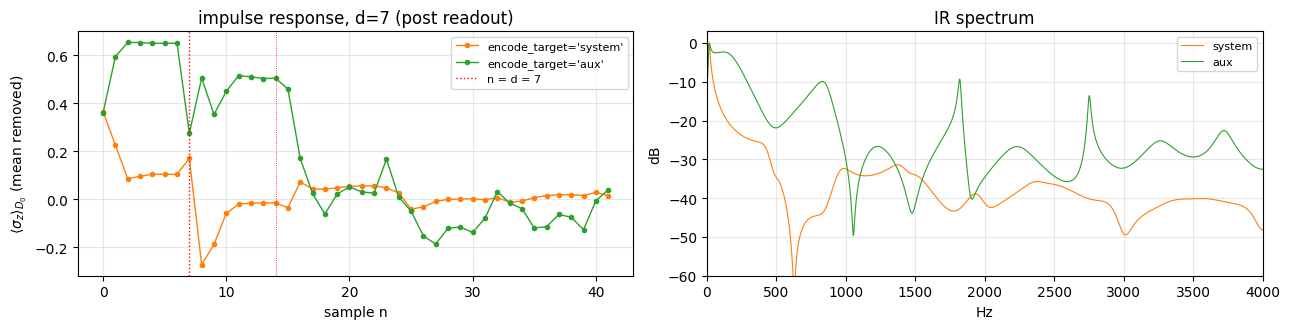

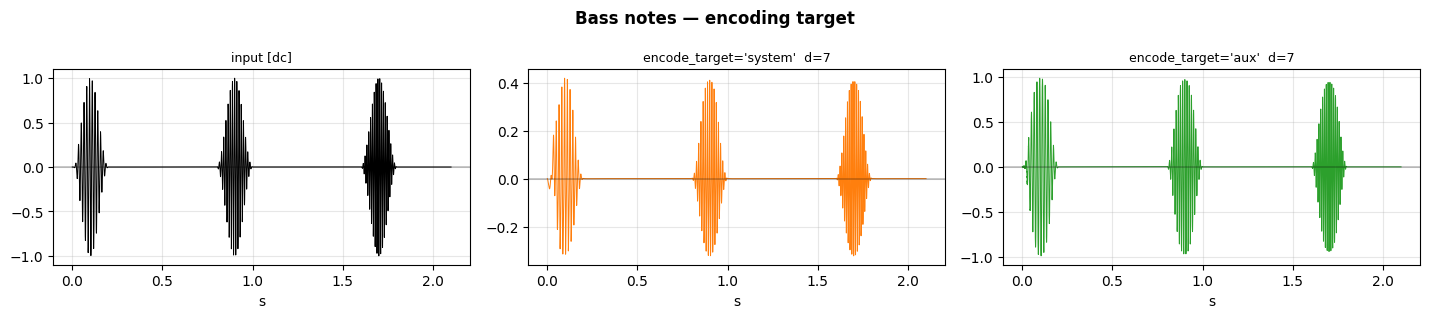

  input [dc]   (peak 0.990)


  encode_target='system'  d=7   (peak 0.419)


  encode_target='aux'  d=7   (peak 0.990)


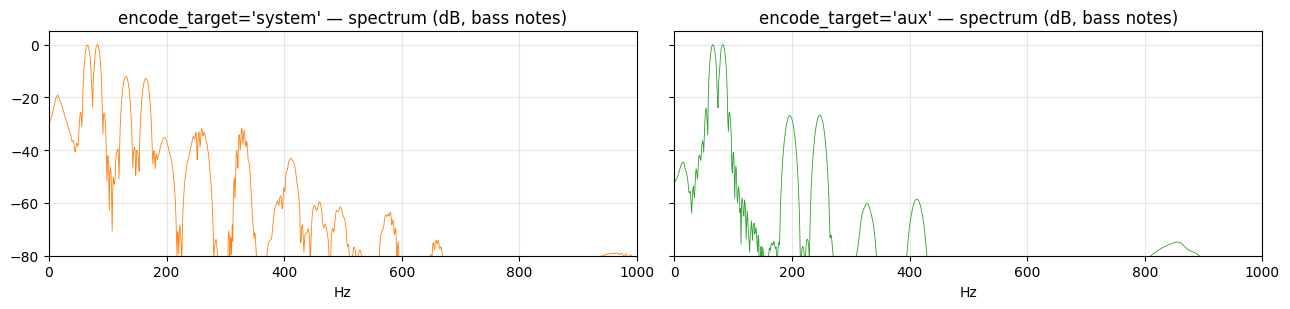

  system : rms 0.090   peak 0.573
  aux    : rms 0.259   peak 0.990


In [4]:
# -- 13. Encoding target: 'system' (default) vs 'aux' -- same input, same params
ENC = [('system', 'tab:orange'), ('aux', 'tab:green')]

# (a) kernel view: impulse response of the channel under both encodings
imp = make_impulse(0.3)
ir = {tgt: run_sensing_raw(imp, encode_target=tgt) for tgt, _ in ENC}
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
for tgt, col in ENC:
    ax[0].plot(ir[tgt][:6*SINGLE_D], '-o', color=col, ms=3, lw=1, label=f"encode_target='{tgt}'")
    Y = 20*np.log10(np.abs(np.fft.rfft(dc_filter(ir[tgt]), n=4096)) + 1e-12)
    ax[1].plot(np.fft.rfftfreq(4096, 1/FS), Y - Y.max(), color=col, lw=0.8, label=tgt)
ax[0].axvline(SINGLE_D, color='r', ls=':', lw=1, label=f'n = d = {SINGLE_D}')
ax[0].axvline(2*SINGLE_D, color='r', ls=':', lw=0.6)
ax[0].set_xlabel('sample n'); ax[0].set_ylabel(r'$\langle\sigma_z\rangle_{D_0}$ (mean removed)')
ax[0].set_title(f'impulse response, d={SINGLE_D} (post readout)'); ax[0].grid(alpha=.3)
ax[0].legend(fontsize=8)
ax[1].set_xlim(0, FS/2); ax[1].set_ylim(-60, 3); ax[1].set_xlabel('Hz'); ax[1].set_ylabel('dB')
ax[1].set_title('IR spectrum'); ax[1].grid(alpha=.3); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# (b) bass notes: the audible comparison (same STRETCH_GAIN applied to both)
outs = {tgt: apply_gain_clip(run_sensing_raw(bass, encode_target=tgt), STRETCH_GAIN)
        for tgt, _ in ENC}
present('Bass notes — encoding target', bass,
        [(f"encode_target='{tgt}'  d={SINGLE_D}", outs[tgt], col) for tgt, col in ENC])
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2), sharey=True)
for a, (tgt, col) in zip(ax, ENC):
    y = fade_edges(dc_filter(outs[tgt]))
    Y = 20*np.log10(np.abs(np.fft.rfft(y, n=8192)) + 1e-12)
    a.plot(np.fft.rfftfreq(8192, 1/FS), Y - Y.max(), color=col, lw=0.6)
    a.set_xlim(0, 1000); a.set_ylim(-80, 5); a.grid(alpha=.3); a.set_xlabel('Hz')
    a.set_title(f"encode_target='{tgt}' — spectrum (dB, bass notes)")
plt.tight_layout(); plt.show()
for tgt, _ in ENC:
    y = outs[tgt]
    print(f"  {tgt:7s}: rms {np.sqrt(np.mean(y**2)):.3f}   peak {np.max(np.abs(y)):.3f}")


## 14. Why the sensing route barely modulates — and why `'aux'` is a near-copy

Everything in this circuit is a single-qubit rotation or a partial SWAP, so it can be
followed on Bloch vectors. For a product state $a$ (on $S$), $b$ (on the other qubit),
the partial SWAP $e^{\,}\cos\theta\,I + i\sin\theta\,\mathrm{SWAP}$ gives

$$a' = c^2 a + s^2 b + sc\,(a\times b),\qquad b' = c^2 b + s^2 a + sc\,(b\times a),\qquad c=\cos\theta,\ s=\sin\theta,$$

a **linear exchange** plus one **bilinear cross term** ($sc = 0.49$ at $\theta=0.9$ —
not small). The readout is the $z$-component of $D_0$.

**`encode_target='aux'`.** The probe enters as $U_{\rm enc}(\varphi)|0\rangle$, Bloch
vector $(0,\,-\cos\varphi,\,\sin\varphi)$: every probe lies in the $yz$-plane and the
sample sits in $z=\sin\varphi[n]$. Nothing ever rotates the register again, so the $z$
components are only *exchanged*, linearly, between $S$, the line and the read-out
qubit. The cross term needs an $x$-component, and the only $x$ in the whole circuit
is the initial $S=|+\rangle$: it produces a decaying, **input-independent** transient
(the 0.65 plateau that dominates the aux panel of the §13 IR plot — it is not the
impulse) and a second-order $\cos\varphi$ amplitude term. Net: the output is, to
$R^2\approx0.97$, a **linear FIR of $\sin\varphi[n]$**:
$0.47\,u[n] + 0.11\,u[n{-}1] + 0.26\,u[n{-}d{-}1] + 0.07\,u[n{-}d{-}2]+\dots$
With $d=7$ samples the echo is $0.9$ ms; a 65–98 Hz note has a 10–15 ms period, the
comb's first notch is at $\approx f_s/(2(d{+}1)) = 500$ Hz, and on the bass the
output is $u[n]$ scaled — a copy of the input, at unity level.

**`encode_target='system'` (default).** The Ramsey gate acts on $S$ *every tick*, and
at $\varphi=0$ it is not the identity but the axis permutation
$(x,y,z)\mapsto(-y,-z,x)$. The memory held in $S$ is cycled through the three axes:
its $z$ is readable only every third pass and in between it is exposed to
$R_z(\varphi[n])$ — products of successive samples. That is the only genuinely
non-commutative modulation in the route. Its price is that the linear gain
collapses (small, sign-alternating taps; rms $\approx0.28$ of the input). At the
notebook's `phase_scale = 0.5` it adds harmonics at $-11$ dB relative to the
fundamental (the $\sin\varphi$ read-out law alone gives $-24$ dB) and $\sim13\%$ of the
render is not a linear filter of $\sin\varphi$; correlation with the input is
still $\approx0.9$.

**Where the strong modulation comes from (14b).** The heavy modulation of §12 is the
*encoding depth*, not the delay line. At `phase_scale` 2 and 10, $|\varphi|$ reaches
5 and 25 rad, $\sin\varphi$ wraps, and the harmonics exceed the fundamental
($+4$ / $+12$ dB) *before any qubit touches another*. Both encodings show it (table
below): it is memoryless wave-shaping by the Ramsey read-out law
$\langle\sigma_z\rangle=\sin\varphi$, on top of which only `system` adds the
non-commutative memory mixing ($23$–$30\%$ of the render not explained by a linear
filter of $\sin\varphi$, vs $3$–$9\%$ for `aux`).

**What the delay line itself cannot do** is *temporal* modulation of bass: $d\le9$
*samples* is $\le1.1$ ms at $f_s=8$ kHz, one seventeenth of a bass period, so the
comb it makes is a phase shift on a bass note. Modulation at the note's own time
scale needs memory of hundreds of samples — impossible at $2^{d+2}$ dimensions —
which is exactly why the dependent route works at the *frame* rate ($d=5$ frames
$=160$ ms).


U_enc(phi=0) as a Bloch rotation matrix: [[0.0, -1.0, -0.0], [-0.0, 0.0, -1.0], [1.0, 0.0, 0.0]]   i.e. (x,y,z) -> (-y,-z,x)
probe prepared by 'aux' at phi=0: [-0. -1.  0.]   (yz-plane, z = sin phi)
partial SWAP(theta=0.9): c^2=0.39 s^2=0.61 sc=0.49;  formula vs exact: max|diff| = 1.1e-16


system: true IR taps / sin(phi_imp)  n=0..10: [-0.077  0.089  0.002 -0.006 -0.     0.    -0.     0.114  0.089 -0.024
 -0.013]
aux   : true IR taps / sin(phi_imp)  n=0..10: [ 0.473  0.112  0.012  0.     0.001  0.    -0.     0.006  0.257  0.069
  0.026]
system: corr(render, input) = 0.937   rms render/input = 0.388   R^2 of a 24-tap linear FIR on sin(phi) = 0.893
aux   : corr(render, input) = 0.865   rms render/input = 1.119   R^2 of a 24-tap linear FIR on sin(phi) = 0.995


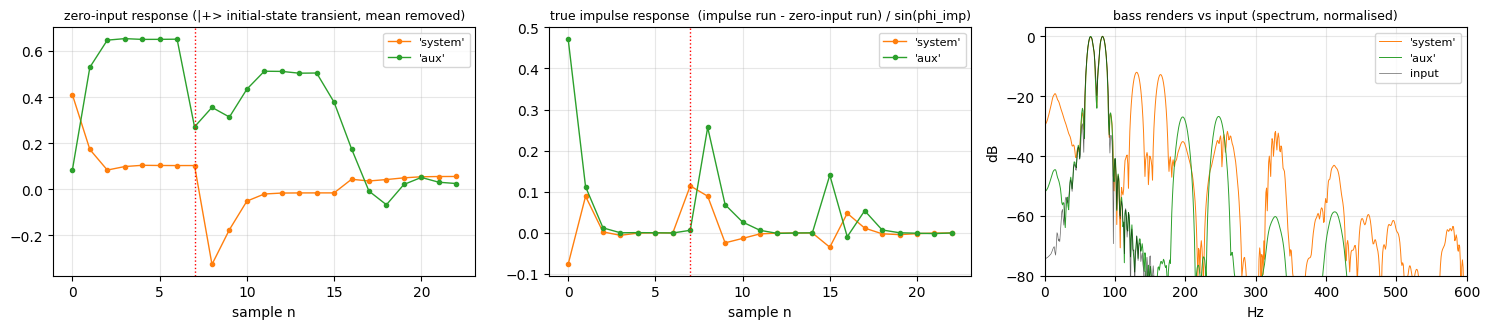

delay d=7 samples = 0.88 ms;  bass periods 15.3-10.2 ms  (d = 1/17 of a C2 period);  comb first notch ~ fs/(2(d+1)) = 500 Hz


In [5]:
# -- 14. why the sensing route barely modulates: Bloch-vector bookkeeping, true IR, linear fit
from qutip import sigmax, sigmay, sigmaz, Qobj, tensor, qeye, expect
from quantum_audio_master import _ramsey_unitary_sinphi, gate_partial_SWAP
sig3 = [sigmax(), sigmay(), sigmaz()]
bloch = lambda rho: np.array([float(np.real(expect(s, rho))) for s in sig3])
dm = lambda v: 0.5*(qeye(2) + v[0]*sigmax() + v[1]*sigmay() + v[2]*sigmaz())

# (1) the Ramsey gate at phi=0 as a Bloch rotation, and the probe it prepares
U0 = _ramsey_unitary_sinphi(0.0)
Rm = np.array([[float(np.real((si*U0*sj*U0.dag()).tr()))/2 for sj in sig3] for si in sig3])
print('U_enc(phi=0) as a Bloch rotation matrix:', np.round(Rm, 3).tolist(), '  i.e. (x,y,z) -> (-y,-z,x)')
print("probe prepared by 'aux' at phi=0:", np.round(bloch(U0*Qobj([[1,0],[0,0]])*U0.dag()), 3), '  (yz-plane, z = sin phi)')

# (2) partial SWAP on product Bloch vectors: linear exchange + bilinear cross term
th = SWAP_IN; c_, s_ = np.cos(th), np.sin(th); Usw = gate_partial_SWAP(th)
a = np.array([1.0, 0, 0]); b = np.array([0, -1.0, 0.3])          # S=|+>, a phi>0 probe
r = Usw*tensor(dm(a), dm(b))*Usw.dag()
pa = c_**2*a + s_**2*b + s_*c_*np.cross(a, b); pb = c_**2*b + s_**2*a + s_*c_*np.cross(b, a)
print(f'partial SWAP(theta={th}): c^2={c_**2:.2f} s^2={s_**2:.2f} sc={s_*c_:.2f};  '
      f'formula vs exact: max|diff| = {max(np.abs(bloch(r.ptrace(0))-pa).max(), np.abs(bloch(r.ptrace(1))-pb).max()):.1e}')

# (3) zero-input response (the |+> initial-state transient) and the TRUE impulse response.
#     Same length as the §13 impulse run (0.3 s), so the mean removal is over the same window.
h0 = {tgt: run_sensing_raw(np.zeros(int(0.3*FS)), encode_target=tgt) for tgt in ('system', 'aux')}
n_show = 3*SINGLE_D + 2
u_imp = np.sin(_compute_phases_from_signal(make_impulse(0.3)*PHASE_SCALE/(0.8/FS), FS, 0.8/FS, 1/FS,
                                           int(0.3*FS), 'ramsey')[0])[0]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
for tgt, col in [('system', 'tab:orange'), ('aux', 'tab:green')]:
    ax[0].plot(h0[tgt][:n_show], '-o', color=col, ms=3, lw=1, label=f"'{tgt}'")
    h_true = (ir[tgt][:n_show] - h0[tgt][:n_show]) / u_imp
    ax[1].plot(h_true, '-o', color=col, ms=3, lw=1, label=f"'{tgt}'")
    print(f"{tgt:6s}: true IR taps / sin(phi_imp)  n=0..{SINGLE_D+3}: {np.round(h_true[:SINGLE_D+4], 3)}")
for A, ttl in zip(ax[:2], ['zero-input response (|+> initial-state transient, mean removed)',
                            f'true impulse response  (impulse run - zero-input run) / sin(phi_imp)']):
    A.axvline(SINGLE_D, color='r', ls=':', lw=1); A.set_xlabel('sample n'); A.set_title(ttl, fontsize=9)
    A.grid(alpha=.3); A.legend(fontsize=8)

# (4) how much of the §13 bass renders is a linear filter of sin(phi)?  (both use the same STRETCH_GAIN)
u = np.sin(_compute_phases_from_signal(bass*PHASE_SCALE/(0.8/FS), FS, 0.8/FS, 1/FS, len(bass), 'ramsey')[0])
L = 24
X = np.column_stack([np.concatenate([np.zeros(k), u[:len(u)-k]]) for k in range(L)] + [np.ones(len(u))])
for tgt, col in [('system', 'tab:orange'), ('aux', 'tab:green')]:
    y = outs[tgt] - np.mean(outs[tgt])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = 1 - np.var(y - X@coef)/np.var(y)
    print(f"{tgt:6s}: corr(render, input) = {np.corrcoef(y, bass)[0,1]:.3f}   rms render/input = "
          f"{np.sqrt(np.mean(y**2))/np.sqrt(np.mean(bass**2)):.3f}   R^2 of a {L}-tap linear FIR on sin(phi) = {r2:.3f}")
    nfft = 8192; Y = np.abs(np.fft.rfft(fade_edges(dc_filter(y)), n=nfft)); Xin = np.abs(np.fft.rfft(fade_edges(dc_filter(bass)), n=nfft))
    fr = np.fft.rfftfreq(nfft, 1/FS)
    ax[2].plot(fr, 20*np.log10(Y/Y.max() + 1e-12), color=col, lw=0.7, label=f"'{tgt}'")
ax[2].plot(fr, 20*np.log10(Xin/Xin.max() + 1e-12), 'k', lw=0.5, alpha=.6, label='input')
ax[2].set_xlim(0, 600); ax[2].set_ylim(-80, 3); ax[2].set_xlabel('Hz'); ax[2].set_ylabel('dB')
ax[2].set_title('bass renders vs input (spectrum, normalised)', fontsize=9); ax[2].grid(alpha=.3); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'delay d={SINGLE_D} samples = {SINGLE_D/FS*1e3:.2f} ms;  bass periods {1e3/NOTE_FREQS[0]:.1f}-{1e3/NOTE_FREQS[-1]:.1f} ms  '
      f'(d = 1/{NOTE_FREQS[0]**-1*FS/SINGLE_D:.0f} of a C2 period);  comb first notch ~ fs/(2(d+1)) = {FS/(2*(SINGLE_D+1)):.0f} Hz')


In [3]:
# -- 14b. where the strong modulation comes from: encoding depth vs encoding target
# short C2 snippet (600 samples) at d=SINGLE_D; both encodings; the phase_scale values of §12
tt = np.arange(600)/FS
x_c2 = np.sin(2*np.pi*NOTE_FREQS[0]*tt)*0.5*(1-np.cos(2*np.pi*tt/(600/FS)))
def _r2(y, u, L=24):
    X = np.column_stack([np.concatenate([np.zeros(k), u[:len(u)-k]]) for k in range(L)] + [np.ones(len(u))])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None); return 1 - np.var(y - X@coef)/np.var(y)
def _harm_dB(y):     # energy 110-1500 Hz vs the fundamental band (40-95 Hz)
    Y = np.abs(np.fft.rfft(y*np.hanning(len(y)), 8192))**2; fr = np.fft.rfftfreq(8192, 1/FS)
    return 10*np.log10(Y[(fr>110)&(fr<1500)].sum()/Y[(fr>40)&(fr<95)].sum())
print(f'{"phase_scale":>11s} {"|phi|max":>8s} {"sin(phi) harm":>13s} | {"target":6s} {"R2 lin sin(phi)":>15s} '
      f'{"R2 lin x":>8s} {"harm/fund":>9s} {"corr(y,x)":>9s} {"rms/in":>6s}')
for ps in (0.5, 2.0, 10.0):
    phi = _compute_phases_from_signal(x_c2*ps/(0.8/FS), FS, 0.8/FS, 1/FS, 600, 'ramsey')[0]; u = np.sin(phi)
    for tgt in ('system', 'aux'):
        y = run_sensing_raw(x_c2, encode_target=tgt, phase_scale=ps)
        print(f'{ps:11.1f} {np.abs(phi).max():8.2f} {_harm_dB(u):+12.0f}dB | {tgt:6s} {_r2(y,u):15.3f} '
              f'{_r2(y,x_c2):8.3f} {_harm_dB(y):+8.0f}dB {np.corrcoef(y,x_c2)[0,1]:9.2f} '
              f'{np.sqrt(np.mean(y**2))/np.sqrt(np.mean(x_c2**2)):6.2f}')
print('R2 = fraction of the render explained by a 24-tap linear filter of sin(phi) (resp. of the input x).')


phase_scale |phi|max sin(phi) harm | target R2 lin sin(phi) R2 lin x harm/fund corr(y,x) rms/in


        0.5     1.23          -24dB | system           0.873    0.882      -11dB      0.92   0.28


        0.5     1.23          -24dB | aux              0.970    0.967      -24dB      0.90   1.09


        2.0     4.92           +4dB | system           0.774    0.168       +5dB      0.06   0.33


        2.0     4.92           +4dB | aux              0.971    0.229       +3dB      0.02   1.35


       10.0    24.58          +12dB | system           0.695    0.126       +8dB     -0.23   0.31


       10.0    24.58          +12dB | aux              0.912    0.075       +9dB     -0.20   1.04
R2 = fraction of the render explained by a 24-tap linear filter of sin(phi) (resp. of the input x).


## Notes

* All quantum outputs above are decoded from the delay-line qubit's
  $\langle\sigma_z\rangle$ **only** — no input sample is ever mixed into an
  output (quantum-as-carrier).
* This deterministic (expectation-value) readout is exactly what masks the
  witnessable quantum correlations — the **dependent-trajectory** notebook is
  the stochastic counterpart, where projective measurement generates true
  trajectories.
* Left aside here: the dual/joint sensing mode (`trotterize_sensing_dual`), the
  Hahn-echo sequence, and the QPSD demodulated readout — see
  `QFDN_vs_Sensing_comparison.ipynb`.